<br/>

<div align="center">
<span style="font-size: 2.5em;">Halo Model Comparison: Realistic Scenarios</span>
<br/>
<span style="font-size: 1.2em; color: gray;">Testing combined posteriors with realistic halo models (SHM, SHMpp, LMC)</span>
</div>

## Overview

This notebook tests the method with **realistic halo models** (SHM, SHMpp, LMC) and their combined posterior. These halos are much more similar than the extreme x1/x2 cases, so differences are expected to be subtle.

We investigate:

- **Coverage Tests**: Are credible regions calibrated under each halo?
- **Accuracy & Precision**: How close MAP estimates are to truth (Euclidean, Mahalanobis) and how sharp posteriors are (volume)
- **Halo Dependence**: How performance degrades under misspecification relative to SHM-like halos

In [ ]:
# =============================
# IMPORTS AND PATH SETTINGS
# =============================

import os
desired_root_name = "xenon-sbi" 
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch
import numpy as np
import matplotlib.pyplot as plt
from configs.config import MCConfig, PARAM_RANGES, load_halo_models
from utils.posteriors import posterior_halo_comparison
from performances.metrics import (
    coverage_halo_comparison,
    evaluate_posterior_quality_halo,
    compare_metric_histograms,
)

In [2]:
# ===========================================
# PARAMETERS TO DEFINE THE DATA AND MODEL 
# ===========================================

modelname = "ntothighest"                
datatag   = "low"
n_train   = 300_000
#halos = ["shm", "lmc"]
halos = ["default", "shm", "shmpp", "lmc"]
halo_choice = "default"

mc_cfg = MCConfig()  
bins = mc_cfg.bins     
top_k     = 10             

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# =============================
# LOAD MODELS
# =============================

models, labels = load_halo_models(
    halos=halos,
    modelname=modelname,
    n_train=n_train,
    datatag=datatag,
    bins=bins,
    top_k=top_k,
    device=device,
)

Loading model from models/wimpy\default\ntothighest_n300000_low_default.pt
Loading model from models/wimpy\shm\ntothighest_n300000_low_shm.pt
Loading model from models/wimpy\shmpp\ntothighest_n300000_low_shmpp.pt
Loading model from models/wimpy\lmc\ntothighest_n300000_low_lmc.pt
Loading combined model from models/wimpy\combined\default_shm_shmpp_lmc\ntothighest_n300000_low_default_shm_shmpp_lmc.pt


## 1. Qualitative Posterior Comparison

Visualize posteriors from different realistic halo models for a single example spectrum to build intuition for subtle halo-dependent shifts.

In [4]:
# ==========================================================
# Wrapper to run halo comparison
# ==========================================================

def run_halo_comparison(m, cp, halo_choice, models, labels, save_path=None):
    posterior_halo_comparison(
        models=models,
        labels=labels,
        mchi_true=m,
        cp_true=cp,
        halo_choice=halo_choice,
        logm_range=PARAM_RANGES[datatag]["logm_range"],
        logcp_range=PARAM_RANGES[datatag]["logcp_range"],
        save_path=save_path,
    )


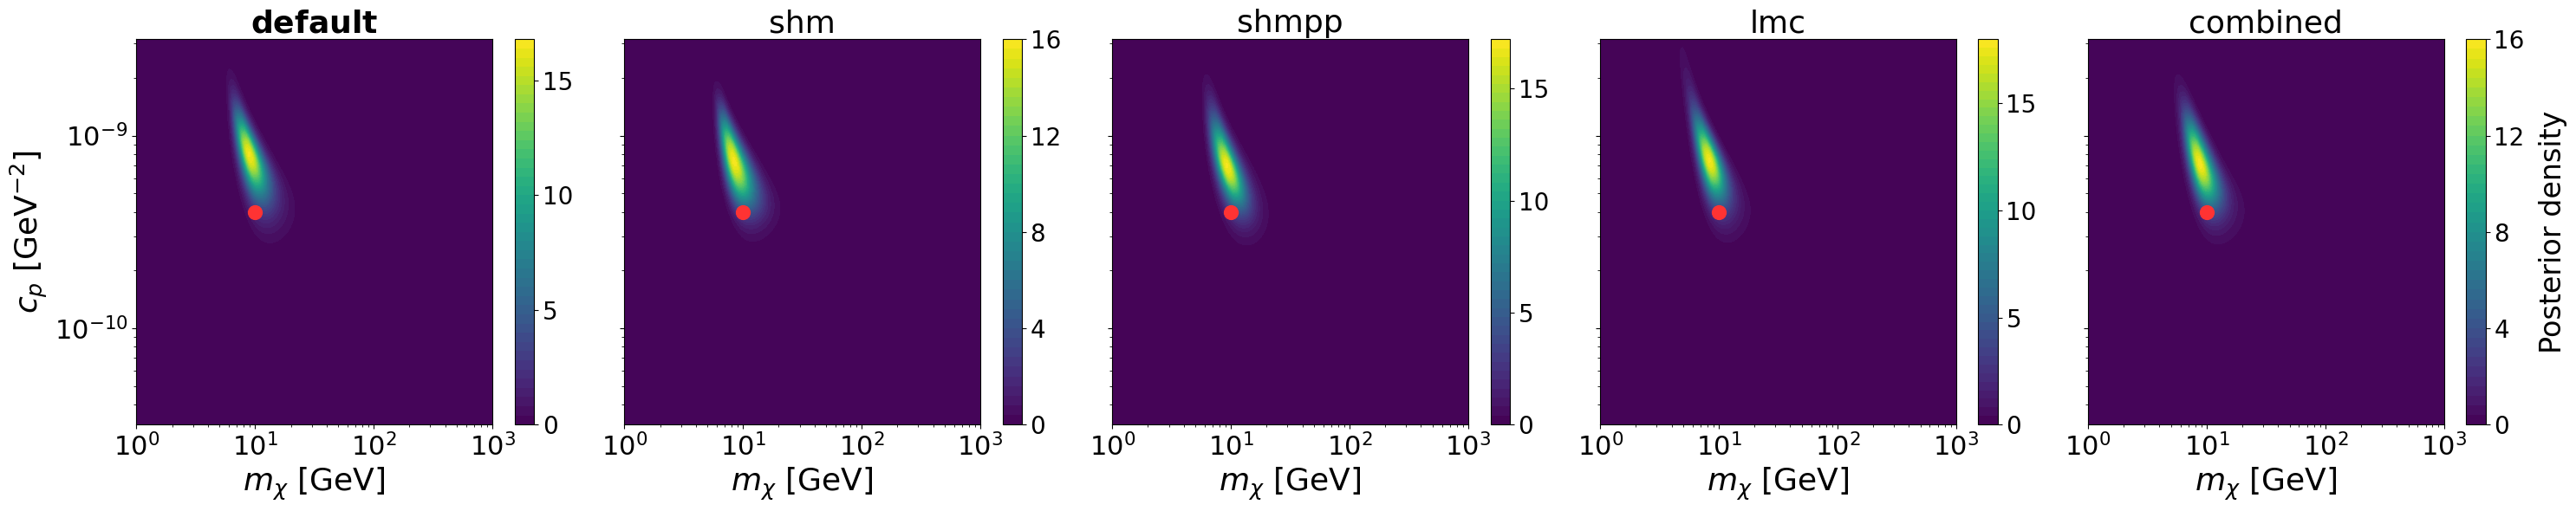

In [ ]:
run_halo_comparison(
    m=10.0, cp=10**(-9.4), 
    halo_choice=halo_choice, 
    models=models, 
    labels=labels,
    #save_path=f"figures/..."
)

## 2. Coverage Analysis

### Full Parameter Space
**Expectation**: Coverage should be best for the correct (default/SHM-like) halo and remain similar across realistic models.

**Key Findings**:
- **Realistic halos** (default/SHM/SHMpp): Very similar coverage
- **LMC**: Small but visible deviations
- **Combined model**: Typically robust across realistic halo assumptions

Loading dataset from:
data/datasets/wimpy/default/wimpy_n300000_low_default.pt

Total test samples: 45107
Running coverage test for: default
Running coverage test for: shm
Running coverage test for: shmpp
Running coverage test for: lmc
Running coverage test for: combined


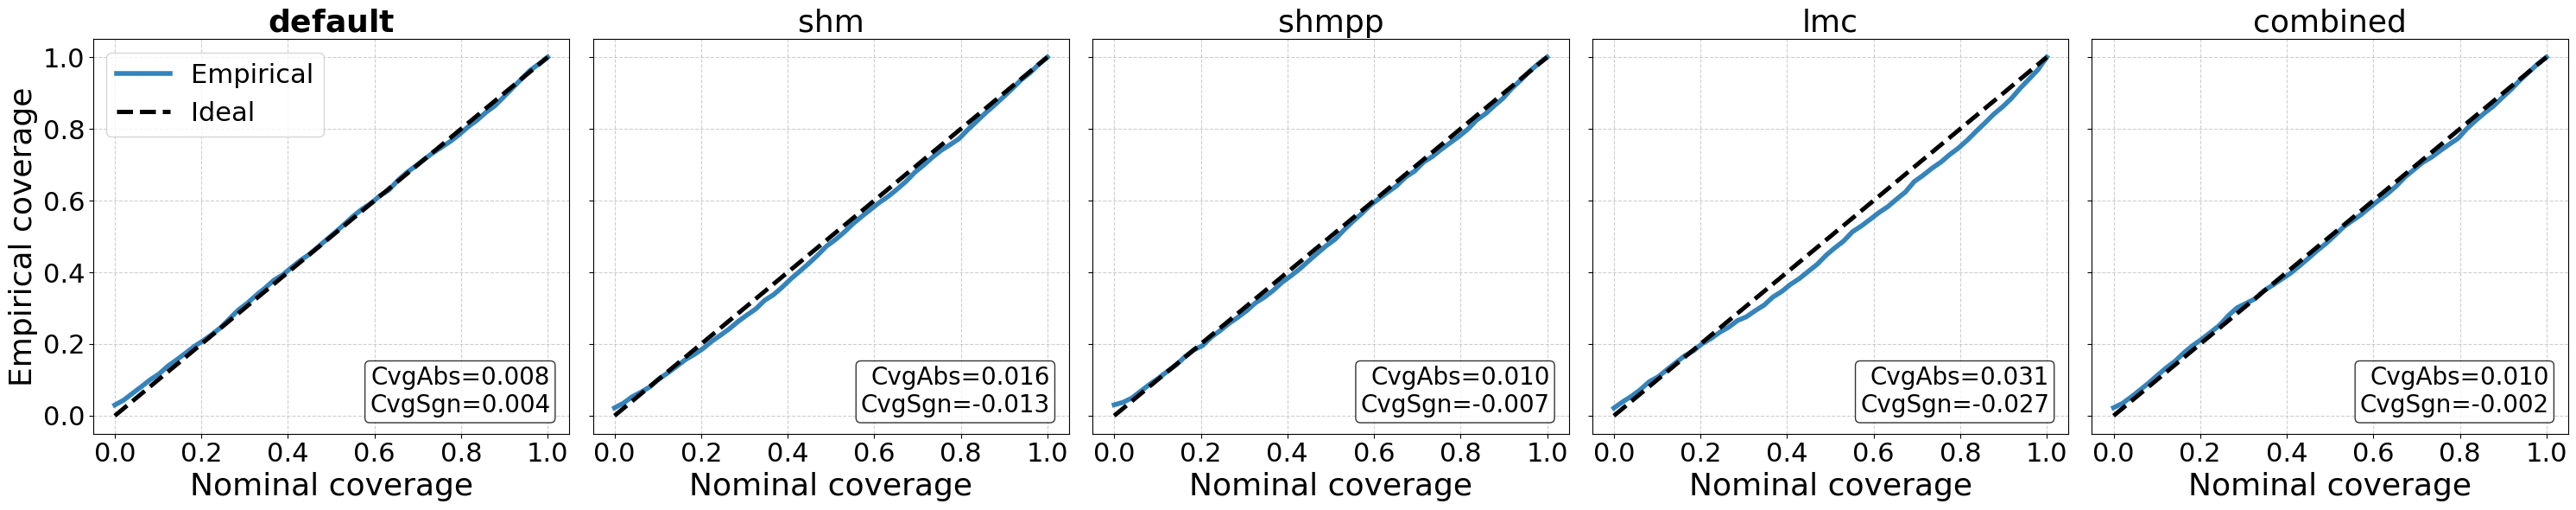

In [ ]:
# ==========================================================
# Coverage comparisons: Full parameter space
# ==========================================================

coverage_halo_comparison(
    models=models,
    labels=labels,
    halo_choice=halo_choice,
    datatag=datatag,
    n_train=n_train,
    logm_range=PARAM_RANGES[datatag]["logm_range"],
    logcp_range=PARAM_RANGES[datatag]["logcp_range"],
    device=device,
    levels=np.linspace(0, 1, 50),
    posteriorbins=50,
    n_samples=2000,
    #avepath=f"figures/...
)

### Focused Parameter Region

We zoom into a low-mass window where halo differences are most pronounced to better expose misspecification effects.

**Note**: Coverage alone does not distinguish overly broad from overly narrow posteriors, so we add accuracy/precision metrics below.

Loading dataset from:
data/datasets/wimpy/default/wimpy_n300000_low_default.pt

Filtered test samples: 8698
Running coverage test for: default
Running coverage test for: shm
Running coverage test for: shmpp
Running coverage test for: lmc
Running coverage test for: combined


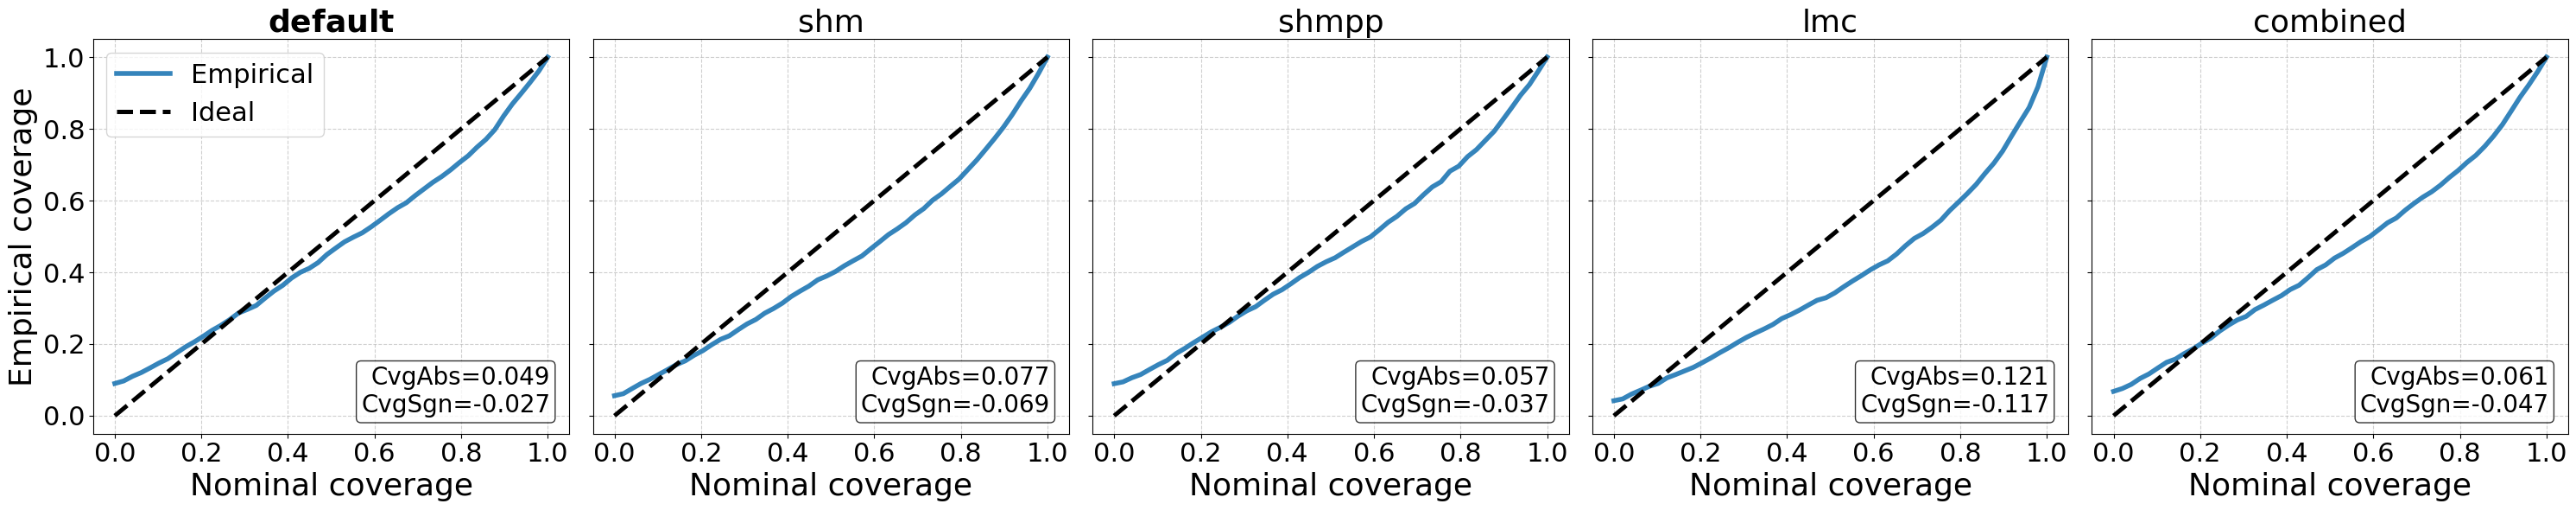

In [ ]:
# ==========================================================
# Coverage comparisons in a smaller parameter space
# ==========================================================

coverage_halo_comparison(
    models=models,
    labels=labels,
    halo_choice=halo_choice,
    datatag=datatag,
    n_train=n_train,
    logm_range=PARAM_RANGES[datatag]["logm_range"],
    logcp_range=PARAM_RANGES[datatag]["logcp_range"],
    device=device,
    levels=np.linspace(0, 1, 50),
    posteriorbins=50,
    n_samples=2000,
    logm_window=(np.log10(5), np.log10(30)),
    logcp_window=(-10, -8.5),
    #savepath=f"figures/...",
 )

## 3. Accuracy & Precision Metrics

Complement coverage tests with direct measurements of posterior accuracy and sharpness. The evaluation excludes zero-event spectra to avoid misleading distances in exclusion regions.

### 3.1 Full Parameter Space (no window)

Metrics computed across the full parameter space (no windowing).

In [6]:
performances = evaluate_posterior_quality_halo(
    models,
    labels,
    halo_choice=halo_choice,
    datatag=datatag,
    n_train=n_train,
    device=device,
    posteriorbins=50,
    n_samples=5000,
)

Loading dataset from:
data/datasets/wimpy/default/wimpy_n300000_low_default.pt

Non-zero test samples: 20639
Evaluating model: default
Evaluating model: shm
Evaluating model: shmpp
Evaluating model: lmc
Evaluating model: combined


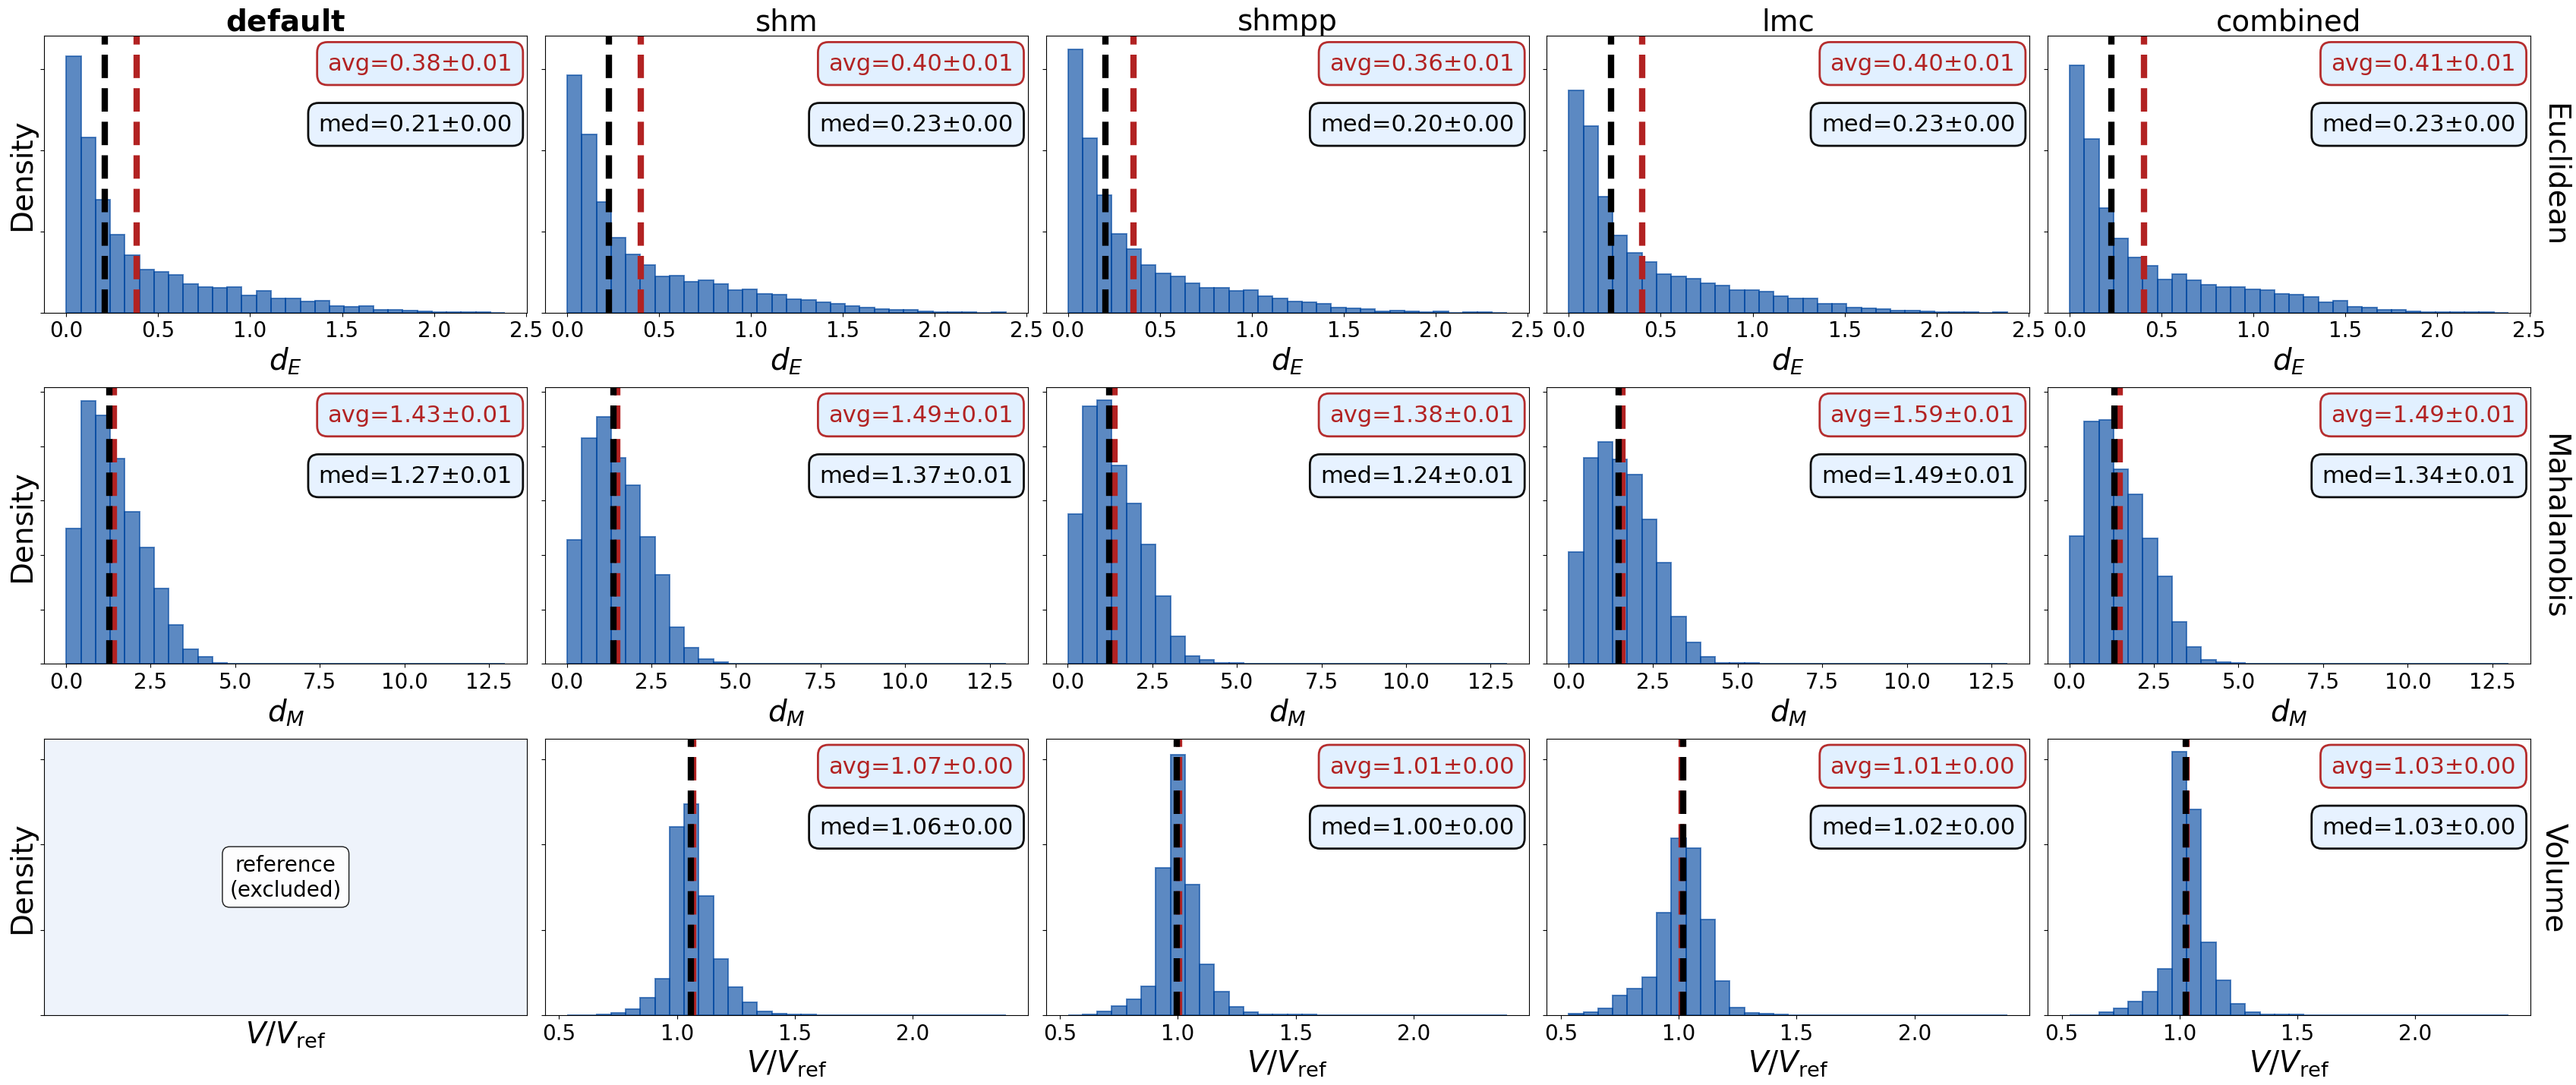

In [ ]:
compare_metric_histograms(
    performances,
    bins=30,
    reference_label=halo_choice,
    axis_label_fontsize=28,
    tick_fontsize=20,
    textbox_fontsize=20,
    annotation_fontsize=28,
    #savepath=f"figures/...",
)

### 3.2 Focused Parameter Window

Same metrics restricted to a focused parameter window to highlight halo-dependent differences.

In [9]:
performances_windowed = evaluate_posterior_quality_halo(
    models,
    labels,
    halo_choice=halo_choice,
    datatag=datatag,
    n_train=n_train,
    device=device,
    posteriorbins=50,
    n_samples=5000,
    logm_window=(np.log10(5), np.log10(30)),
    logcp_window=(-10, -8.5),
)

Loading dataset from:
data/datasets/wimpy/default/wimpy_n300000_low_default.pt

Filtered test samples: 8698
Non-zero test samples: 6477
Evaluating model: default
Evaluating model: shm
Evaluating model: shmpp
Evaluating model: lmc
Evaluating model: combined


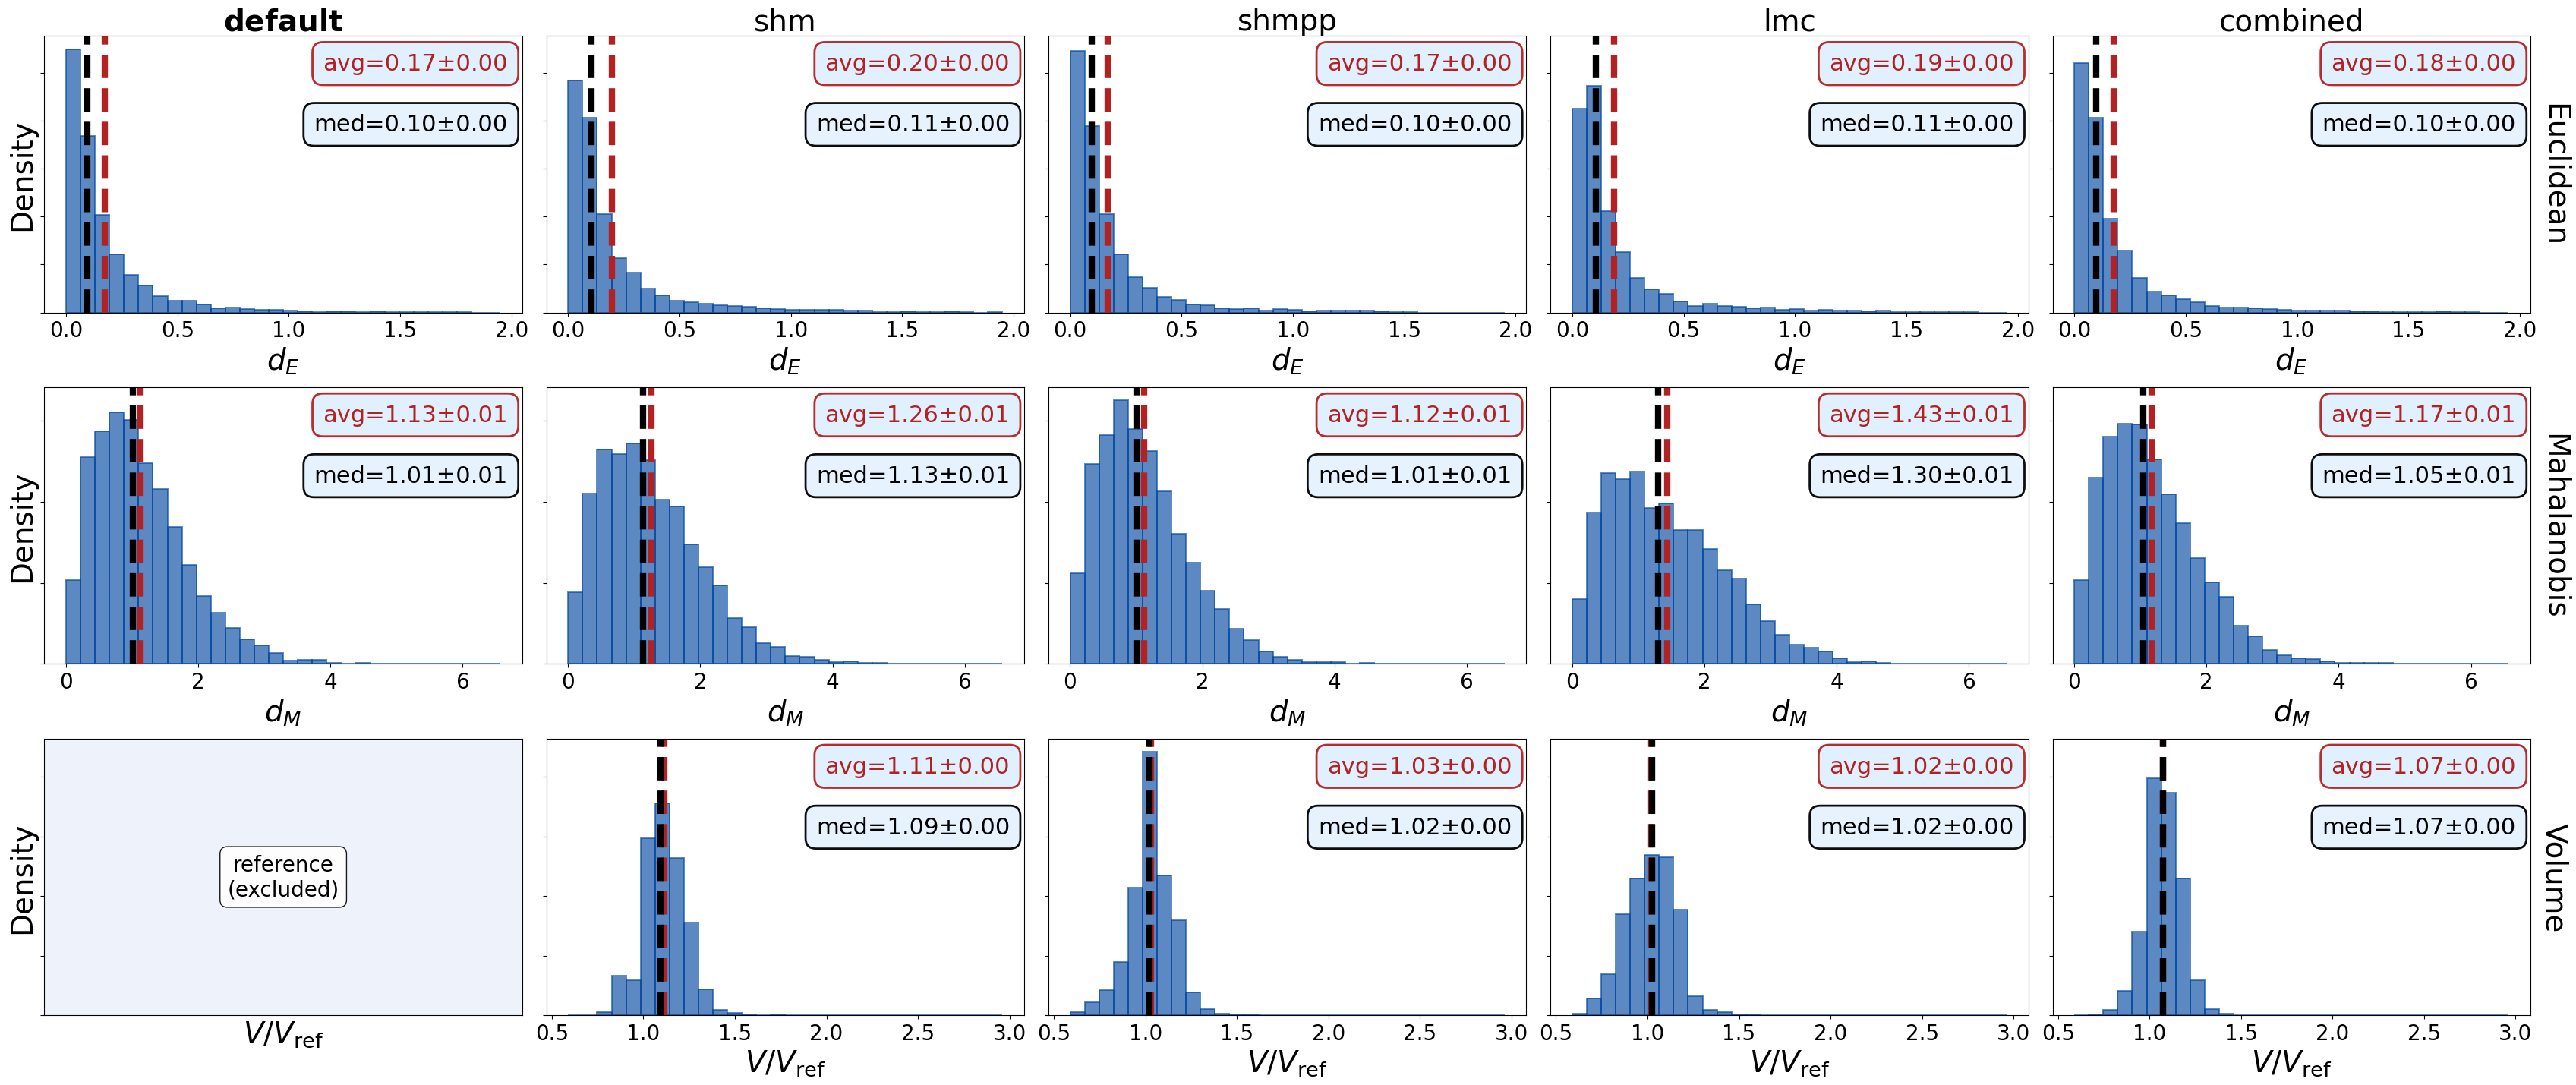

In [ ]:
compare_metric_histograms(
    performances_windowed,
    bins=30,
    reference_label=halo_choice,
    axis_label_fontsize=28,
    tick_fontsize=20,
    textbox_fontsize=20,
    annotation_fontsize=28,
    #savepath=f"figures/...",
)